In [31]:
from src.imports import *
np.random.seed(42)
#ignore warnings
import warnings
warnings.filterwarnings("ignore")

#open figs folder txt file to read the path
with open('./fig_folder.txt', 'r') as f:
    fig_folder = f.read().strip()

In [32]:
#read topics from txt
topics = []
with open('./data/processed/txt/big_issues_topics.txt', 'r') as f:
    for line in f:
        topics.append(line.strip())
print(f"Total topics loaded: {len(topics)}")
topics = [str.lower() for str in topics]

Total topics loaded: 48


In [33]:
summary_df = pd.read_csv('./results/regression/gpt/summary.csv',index_col=0)
topic_mapping = pd.read_pickle('./results/regression/gpt/topic_mapping.pkl')
classification_df = pd.read_csv('./results/regression/gpt/classification.csv')

In [34]:
# ----------------------------
# Color and alpha mappings
# ----------------------------
class_colors = {
    "conviction-only":           "#0072B2",  # blue
    "conviction-driven":         "#56B4E9",  # sky blue
    "weakly conviction-driven":  "#B3D9F2",  # pale blue

    "conformity-only":           "#D55E00",  # vermillion
    "conformity-driven":         "#E69F00",  # orange
    "weakly conformity-driven":  "#F6C667",  # pale orange

    "jointly-driven":            "#CC79A7",  # reddish purple

    "indeterminate":             "#999999",  # neutral grey
}
class_alphas = {
    "conviction-only":           0.45,
    "conviction-driven":         0.35,
    "weakly conviction-driven":  0.22,

    "conformity-only":           0.45,
    "conformity-driven":         0.35,
    "weakly conformity-driven":  0.22,

    "jointly-driven":            0.45,

    "indeterminate":             0.12,
}
class_text_alphas = {
    "conviction-only":           1.0,
    "conviction-driven":         1.0,
    "weakly conviction-driven":  0.75,

    "conformity-only":           1.0,
    "conformity-driven":         1.0,
    "weakly conformity-driven":  0.75,

    "jointly-driven":            1.0,

    "indeterminate":             0.55,
}
class_markers = {
    "conviction-only": "o",
    "conviction-driven": "o",
    "weakly conviction-driven": "o",

    "conformity-only": "s",
    "conformity-driven": "s",
    "weakly conformity-driven": "s",

    "jointly-driven": "D",

    "indeterminate": "^",
}

In [35]:
#assign topics to issues
topic_groups = {
    'social welfare, healthcare, and education': ['homeschooling', 'medicaid & medicare', 'national health care', 'social security', 'social programs', 'welfare'],
    'economy, budget, and taxes': ['capitalism', 'estate tax', 'federal reserve','flat tax', 'gold standard', 'labor union','minimum wage','national retail sales tax', 'occupy movement', 'progressive tax','redistribution','socialism', 'stimulus spending'],
    'social and cultural issues': ['abortion', 'civil unions', 'drug legalization','euthanasia','gay marriage', 'internet censorship', 'legalized prostitution', 'medical marijuana', 'smoking ban'],
    'guns and crime': ['death penalty', 'gun rights', 'torture'],
    'military and foreign policy': ['european union', 'iran-iraq war', 'military intervention','united nations','war in afghanistan', 'war on terror'],
    'immigration, trade, and globalization': ['border fence', 'free trade', 'globalization'],
    'race': ['affirmative action', 'racial profiling'],
    'environment': ['animal rights', 'environmental protection', 'global warming exists'],
    'government and politics': ['barack obama', 'electoral college', 'term limits']
    }

#check if all topics are covered
all_topics = [topic for sublist in topic_groups.values() for topic in sublist]
missing_topics = set(topics) - set(all_topics)
if missing_topics:
    print(f"Warning: The following topics are missing from topic_groups: {missing_topics}")

#check if there are topics in topic_groups that are not in topics
extra_topics = set(all_topics) - set(topics)
if extra_topics:
    print(f"Warning: The following topics in topic_groups are not in the data topics: {extra_topics}")

# Build topic → issue mapping
topic_to_issue = {
    topic: issue
    for issue, topics in topic_groups.items()
    for topic in topics
}

## Prepare data

In [36]:
beta_phi_df = summary_df.loc[summary_df.index.str.startswith('beta_phi')].copy()
beta_tau_df = summary_df.loc[summary_df.index.str.startswith('beta_tau')].copy()
print(f"beta_phi_df shape: {beta_phi_df.shape}")
print(f"beta_tau_df shape: {beta_tau_df.shape}")

# Extract the number between [ ] and convert to nullable integer
beta_phi_df['topic_idx'] = (
    beta_phi_df.index.astype(str)
    .str.extract(r'\[\s*(\d+)\s*\]', expand=False)
    .astype('Int64')
)
beta_tau_df['topic_idx'] = (
    beta_tau_df.index.astype(str)
    .str.extract(r'\[\s*(\d+)\s*\]', expand=False)
    .astype('Int64')
)

# Map to topic labels using topic_mapping (1-based keys)
beta_phi_df['topic'] = beta_phi_df['topic_idx'].map(topic_mapping)
beta_tau_df['topic'] = beta_tau_df['topic_idx'].map(topic_mapping)

# Sort by posterior mean descending
beta_phi_df = beta_phi_df.sort_values('Mean', ascending=True)
beta_tau_df = beta_tau_df.sort_values('Mean', ascending=True)

#add issue column by mapping topic to issue
beta_phi_df['issue'] = beta_phi_df['topic'].map(topic_to_issue)
beta_tau_df['issue'] = beta_tau_df['topic'].map(topic_to_issue)

# Merge the two dataframes on 'topic'
beta_df = beta_phi_df.merge(
    beta_tau_df,
    on="topic",
    suffixes=("_phi", "_tau")
)
beta_df["issue"] = beta_df["issue_phi"]

xlim = (
    beta_df['5%_phi'].min(),
    beta_df['95%_phi'].max()
)

ylim = (
    beta_df['5%_tau'].min(),
    beta_df['95%_tau'].max()
)


beta_phi_df shape: (47, 11)
beta_tau_df shape: (47, 11)


## Fig 2 Topic-specific parameter estimates.

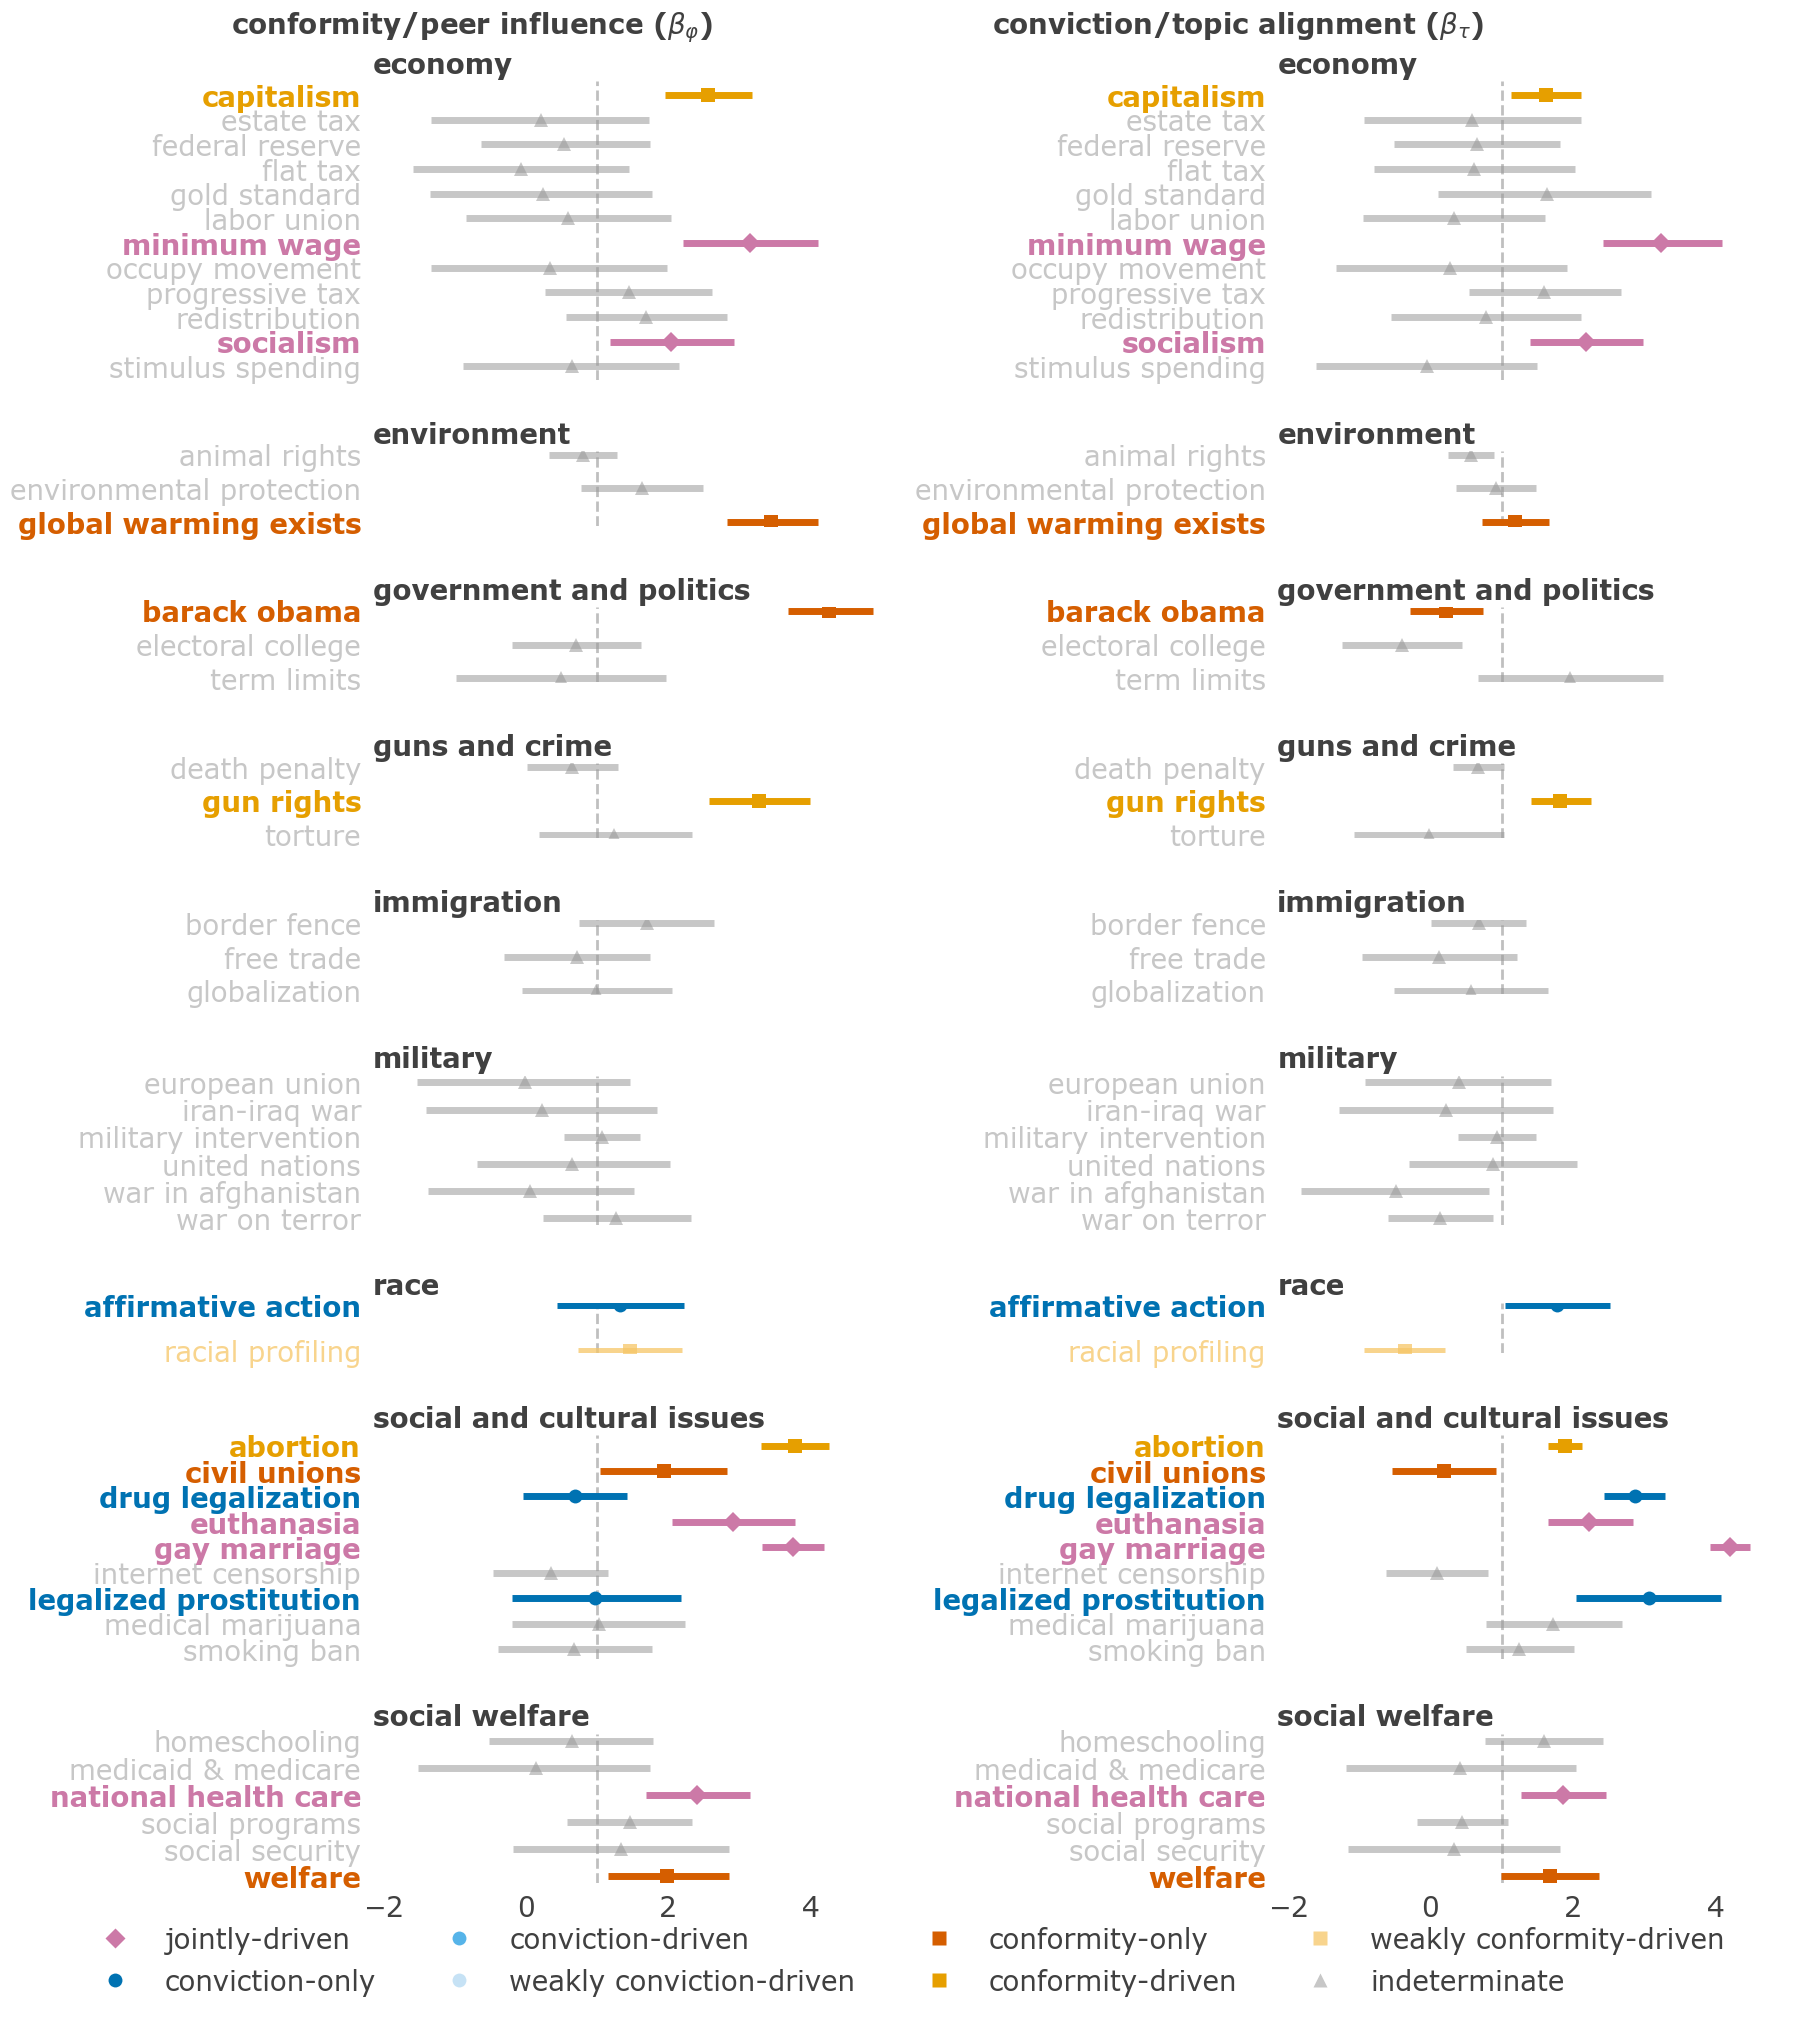

In [37]:
fontsz = 20
fontsz_small = 20

class_text_alphas = {
    "conviction-only":           1.0,
    "conviction-driven":         1.0,
    "weakly conviction-driven":  0.75,

    "conformity-only":           1.0,
    "conformity-driven":         1.0,
    "weakly conformity-driven":  0.75,

    "jointly-driven":            1.0,

    "indeterminate":             0.55,
}

class_alphas = class_text_alphas
# ----------------------------
# Build topic → issue-topic mapping
# ----------------------------
topic_to_issue = {
    topic: issue
    for issue, topics in topic_groups.items()
    for topic in topics
}

beta_phi_df['issue'] = beta_phi_df['topic'].map(topic_to_issue)
beta_tau_df['issue'] = beta_tau_df['topic'].map(topic_to_issue)

# ----------------------------
# Add class info
# ----------------------------
topic_to_class = dict(zip(classification_df['topic'], classification_df['class']))

beta_phi_df['class'] = beta_phi_df['topic'].map(topic_to_class)
beta_tau_df['class'] = beta_tau_df['topic'].map(topic_to_class)

# ----------------------------
# Forest plot function
# ----------------------------
def plot_forest(ax, df, title):

    ytick_alpha = []

    for i, (_, row) in enumerate(df.iterrows()):

        mean  = row['Mean']
        lower = row['5%']
        upper = row['95%']

        cls = row['class']

        color      = class_colors.get(cls, "#999999")
        alpha      = class_alphas.get(cls, 0.2)
        alpha_text = class_text_alphas.get(cls, 1.0)
        marker     = class_markers.get(cls, "o")

        ax.errorbar(
            mean,
            i,
            xerr=[[mean - lower], [upper - mean]],
            fmt=marker,
            capsize=5,
            color=color,
            ecolor=color,
            alpha=alpha,
            elinewidth=5,
            markeredgewidth=0,
            markersize=10,
            zorder=3
        )

        ytick_alpha.append(alpha_text)

    # reference line
    ax.axvline(1, linestyle='--', color='grey', alpha=0.5)

    # ticks
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df['topic'], fontsize=fontsz_small)

    for tick, alpha in zip(ax.get_yticklabels(), ytick_alpha):

        topic = tick.get_text()
        cls = topic_to_class.get(topic, "indeterminate")

        tick.set_color(class_colors.get(cls, "#999999"))
        tick.set_alpha(alpha)

        if alpha >= 1.0:
            tick.set_fontweight('bold')
        else:
            tick.set_fontweight('normal')

    ax.tick_params(axis='x', labelsize=fontsz_small)

    # cleaner titles
    if title == 'immigration, trade, and globalization':
        issue_title = 'immigration'
    elif title == 'military and foreign policy':
        issue_title = 'military'
    elif title == 'social welfare, healthcare, and education':
        issue_title = 'social welfare'
    elif title == 'economy, budget, and taxes':
        issue_title = 'economy'
    else:
        issue_title = title

    ax.set_title(issue_title, fontsize=fontsz, fontweight='bold')


# ----------------------------
# Layout
# ----------------------------
issues = sorted(beta_phi_df['issue'].dropna().unique())

height_ratios = [
    beta_phi_df[beta_phi_df['issue'] == issue].shape[0]
    for issue in issues
]

fig, axes = plt.subplots(
    nrows=len(issues),
    ncols=2,
    figsize=(18, 0.4 * sum(height_ratios)),
    sharex=True,
    gridspec_kw={"height_ratios": height_ratios,"hspace": 0.18},
    constrained_layout=True
)

if len(issues) == 1:
    axes = axes.reshape(1, 2)

# ----------------------------
# Plot panels
# ----------------------------
for r, issue in enumerate(issues):

    phi_sub = (
        beta_phi_df[beta_phi_df['issue'] == issue]
        .sort_values('topic', ascending=False)
    )

    tau_sub = (
        beta_tau_df[beta_tau_df['issue'] == issue]
        .sort_values('topic', ascending=False)
    )

    plot_forest(
        axes[r, 0],
        phi_sub,
        issue
    )

    plot_forest(
        axes[r, 1],
        tau_sub,
        issue
    )

# ----------------------------
# Column headers
# ----------------------------
left_center = axes[0, 0].get_position().x0
right_center = axes[0, 1].get_position().x0

fig.text(
    left_center,
    1.02,
    r"conformity/peer influence ($\beta_\varphi$)",
    ha="left",
    va="top",
    fontsize=fontsz,
    fontweight='bold'
)

fig.text(
    right_center,
    1.02,
    r"conviction/topic alignment ($\beta_\tau$)",
    ha="left",
    va="top",
    fontsize=fontsz,
    fontweight='bold'
)

# ----------------------------
# Legend
# ----------------------------
from matplotlib.lines import Line2D

legend_order = [
    "jointly-driven",
    "conviction-only",
    "conviction-driven",
    "weakly conviction-driven",
    "conformity-only",
    "conformity-driven",
    "weakly conformity-driven",
    "indeterminate",
]

legend_elements = [
    Line2D(
        [0], [0],
        marker=class_markers[c],
        color='none',
        markerfacecolor=class_colors[c],
        markeredgecolor='none',
        alpha=class_alphas[c],
        markersize=10,
        label=c
    )
    for c in legend_order
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=4,
    fontsize=fontsz_small,
    frameon=False
)

# ----------------------------
# Save and show
# ----------------------------
plt.savefig(
    "./plots/Fig2.pdf",
    bbox_inches='tight'
)


plt.show()

## Fig.3 Comparing parameter estimates across issues

In [38]:
# ----------------------------
# Plot function
# ----------------------------
import math

from matplotlib.patches import Ellipse
from adjustText import adjust_text
def add_confidence_ellipse(ax, x, y, x_low, x_high, y_low, y_high, color, alpha=0.2):
    '''
    Add a confidence ellipse to the plot based on the provided confidence intervals for x and y.
     - ax: The matplotlib axis to which the ellipse will be added.
     - x, y: The center coordinates of the ellipse (mean values).
     - x_low, x_high: The lower and upper bounds of the confidence interval for x.
     - y_low, y_high: The lower and upper bounds of the confidence interval for y.
     - color: The color of the ellipse.
     - alpha: The transparency level of the ellipse (default is 0.2).
     The ellipse is calculated based on the standard deviations derived from the confidence intervals, assuming a normal distribution and a 90% confidence level (z-score of approximately 1.645). 
     The width and height of the ellipse are set to represent the confidence intervals for x and y, respectively.
    '''

    sigma_x = (x_high - x_low) / (2 * 1.645)
    sigma_y = (y_high - y_low) / (2 * 1.645)

    ellipse = Ellipse(
        (x, y),
        width=2 * sigma_x * 1.645,
        height=2 * sigma_y * 1.645,
        angle=0,
        edgecolor=color,
        facecolor=color,
        alpha=alpha,           
        linewidth=1.2         
    )

    ax.add_patch(ellipse)

def plot_issue_panel(ax, df_issue, issue, delta_df_, is_leftmost=False, is_bottom=False):

    texts = []

    for _, row in df_issue.iterrows():

        # x and y coordinates for the point, topic label, and class-based styling
        x = row['Mean_phi']
        y = row['Mean_tau']
        topic = row['topic']

        cls = delta_df_.loc[delta_df_['topic'] == topic]['class'].values[0]
        color      = class_colors.get(cls, "#999999")
        alpha      = class_alphas.get(cls, 0.2)
        alpha_text = class_text_alphas.get(cls, 1.0)
        marker     = class_markers.get(cls, "o")

        # add CI
        add_confidence_ellipse(
            ax,
            x, y,
            row['5%_phi'], row['95%_phi'],
            row['5%_tau'], row['95%_tau'],
            color,
            alpha=alpha
        )

        #plot scatter point
        ax.scatter(
            x, y,
            color=color,
            marker=marker,
            s=20 + 2 * fontsz,
            zorder=3,
            alpha=alpha
        )

        #plot text
        texts.append(
            ax.text(x, y, topic, fontsize=fontsz_small, zorder=4, alpha=alpha_text)
        )

    #adjust text to prevent overlap
    adjust_text(
        texts,
        ax=ax,
        arrowprops=dict(arrowstyle='-', color='grey', lw=0.5, alpha=0.5),
        force_text=0.5,
        force_points=0.3
    )

    # reference lines
    x_line = np.linspace(xlim[0], xlim[1], 100)
    ax.plot(x_line, x_line, linestyle='--', color='grey', zorder=1, alpha=0.5)
    ax.axhline(0, linestyle='--', color='grey', alpha=0.5, zorder=1)
    ax.axvline(0, linestyle='--', color='grey', alpha=0.5, zorder=1)

    # threshold lines at beta=1
    ax.axhline(1, linestyle=':', color='grey', alpha=0.4, zorder=1)
    ax.axvline(1, linestyle=':', color='grey', alpha=0.4, zorder=1)

    # appropriate ticks and labels
    ax.set_yticks(np.arange(math.floor(ylim[0]), math.ceil(ylim[1]) + 0.5, 1))
    ax.set_xticks(np.arange(math.floor(xlim[0]), math.ceil(xlim[1]) + 0.5, 1))
    ax.tick_params(axis='both', labelsize=fontsz_small)

    if not is_leftmost:
        ax.set_yticklabels([])
    if not is_bottom:
        ax.set_xticklabels([])

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    #shorter issue titles
    if issue == 'immigration, trade, and globalization':
        issue_title = 'immigration'
    elif issue == 'military and foreign policy':
        issue_title = 'military'
    elif issue == 'social welfare, healthcare, and education':
        issue_title = 'social welfare'
    elif issue == 'economy, budget, and taxes':
        issue_title = 'economy'
    else:
        issue_title = issue
    ax.set_title(issue_title, fontweight='bold', fontsize=fontsz)


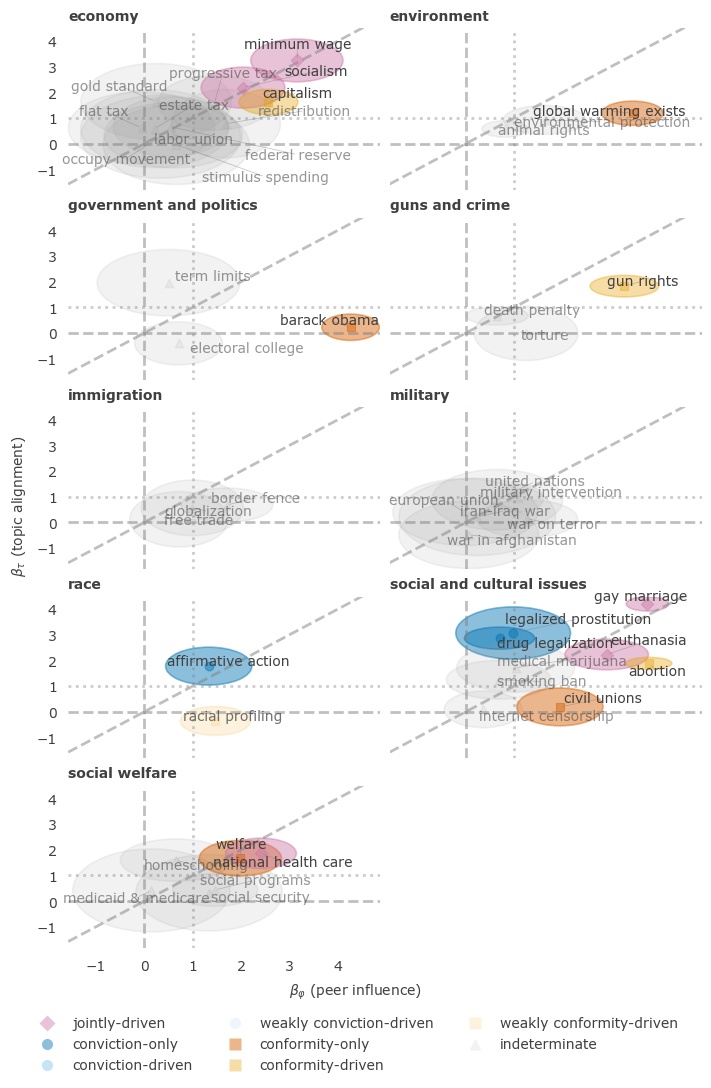

In [41]:
# ----------------------------
# Subplots
# ----------------------------
fontsz = 10
fontsz_small = 10

class_alphas = {
    "conviction-only":           0.45,
    "conviction-driven":         0.35,
    "weakly conviction-driven":  0.22,

    "conformity-only":           0.45,
    "conformity-driven":         0.35,
    "weakly conformity-driven":  0.22,

    "jointly-driven":            0.45,

    "indeterminate":             0.12,
}
class_text_alphas = {
    "conviction-only":           1.0,
    "conviction-driven":         1.0,
    "weakly conviction-driven":  0.75,

    "conformity-only":           1.0,
    "conformity-driven":         1.0,
    "weakly conformity-driven":  0.75,

    "jointly-driven":            1.0,

    "indeterminate":             0.55,
}

issues = sorted(beta_df["issue"].dropna().unique())

n_issues = len(issues)
ncols = 2
nrows = math.ceil(n_issues / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(3.5 * ncols, 2 * nrows),
    constrained_layout=True
)

axes = np.atleast_2d(axes)

# ----------------------------
# Plot
# ----------------------------
for i, issue in enumerate(issues):
    row = i // ncols
    col = i % ncols
    ax = axes[row, col]

    df_issue = beta_df[beta_df["issue"] == issue]

    last_row = (n_issues - 1) // ncols

    is_leftmost = (col == 0)
    is_bottom = (row == last_row)

    plot_issue_panel(ax, df_issue, issue, classification_df, is_leftmost=is_leftmost, is_bottom=is_bottom)

fig.supxlabel(r'$\beta_\varphi$ (peer influence)', fontsize=fontsz)
fig.supylabel(r'$\beta_\tau$ (topic alignment)', fontsize=fontsz)

# ----------------------------
# Legend
# ----------------------------
from matplotlib.lines import Line2D

legend_order = [
    "jointly-driven",
    "conviction-only",
    "conviction-driven",
    "weakly conviction-driven",
    "conformity-only",
    "conformity-driven",
    "weakly conformity-driven",
    "indeterminate",
]

legend_elements = [
    Line2D(
        [0], [0],
        marker=class_markers[c],
        color='none',
        markerfacecolor=class_colors[c],
        markeredgecolor='none',
        alpha=class_alphas[c],
        markersize=8,
        label=c
    )
    for c in legend_order
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    fontsize=fontsz_small,
    frameon=False
)

# ----------------------------
# Remove empty axes
# ----------------------------
for j in range(n_issues, nrows * ncols):
    row = j // ncols
    col = j % ncols
    axes[row, col].axis("off")

# ----------------------------
# Save and show
# ----------------------------
plt.savefig("./plots/Fig3.pdf", bbox_inches='tight')
plt.savefig(f"{fig_folder}/Fig3.pdf", bbox_inches='tight')
plt.show()

### Interactive version

In [40]:
import json
import math
import numpy as np
import pandas as pd
import plotly.graph_objects as go

CLASS_COLORS = {
    "conviction-only":           "#0072B2",
    "conviction-driven":         "#56B4E9",
    "weakly conviction-driven":  "#B3D9F2",
    "conformity-only":           "#D55E00",
    "conformity-driven":         "#E69F00",
    "weakly conformity-driven":  "#F6C667",
    "jointly-driven":            "#CC79A7",
    "indeterminate":             "#999999",
}

CLASS_ALPHAS = {
    "conviction-only":           0.45,
    "conviction-driven":         0.35,
    "weakly conviction-driven":  0.22,
    "conformity-only":           0.45,
    "conformity-driven":         0.35,
    "weakly conformity-driven":  0.22,
    "jointly-driven":            0.45,
    "indeterminate":             0.12,
}

CLASS_TEXT_ALPHAS = {
    "conviction-only":           1.0,
    "conviction-driven":         1.0,
    "weakly conviction-driven":  0.75,
    "conformity-only":           1.0,
    "conformity-driven":         1.0,
    "weakly conformity-driven":  0.75,
    "jointly-driven":            1.0,
    "indeterminate":             0.55,
}

CLASS_SYMBOLS = {
    "conviction-only":           "circle",
    "conviction-driven":         "circle",
    "weakly conviction-driven":  "circle",
    "conformity-only":           "square",
    "conformity-driven":         "square",
    "weakly conformity-driven":  "square",
    "jointly-driven":            "diamond",
    "indeterminate":             "triangle-up",
}

LEGEND_ORDER = [
    "jointly-driven",
    "conviction-only",
    "conviction-driven",
    "weakly conviction-driven",
    "conformity-only",
    "conformity-driven",
    "weakly conformity-driven",
    "indeterminate",
]

XLIM = (-2, 5)
YLIM = (-2, 5)
N_ELLIPSE_PTS = 120


def hex_to_rgba(hex_color, alpha):
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{alpha:.3f})"


def make_ellipse_xy(cx, cy, rx, ry, n=N_ELLIPSE_PTS):
    t = np.linspace(0, 2 * math.pi, n)
    return cx + rx * np.cos(t), cy + ry * np.sin(t)


def build_figure(merged_df, delta_df):
    df = merged_df.merge(delta_df[["topic", "class"]], on="topic", how="left")
    issues = sorted(df["issue"].dropna().unique())
    issue_options = ["all"] + list(issues)

    fig = go.Figure()

    # reference lines (always visible)
    x_ref = [XLIM[0], XLIM[1]]
    y_ref = [YLIM[0], YLIM[1]]
    ref_kw = dict(mode="lines", line=dict(color="grey", dash="dash", width=1),
                  opacity=0.4, showlegend=False, hoverinfo="skip")
    thr_kw = dict(mode="lines", line=dict(color="grey", dash="dot", width=0.8),
                  opacity=0.4, showlegend=False, hoverinfo="skip")
    fig.add_trace(go.Scatter(x=x_ref,  y=x_ref,  **ref_kw))
    fig.add_trace(go.Scatter(x=x_ref,  y=[0, 0], **ref_kw))
    fig.add_trace(go.Scatter(x=[0, 0], y=y_ref,  **ref_kw))
    fig.add_trace(go.Scatter(x=x_ref,  y=[1, 1], **thr_kw))
    fig.add_trace(go.Scatter(x=[1, 1], y=y_ref,  **thr_kw))
    n_ref = 5

    # data traces: for every (issue_filter x class) combination add
    #   one ellipse trace per topic row  (kind="ellipse")
    #   one scatter trace per class      (kind="scatter")
    trace_meta = []
    legend_shown = set()

    for issue_filter in issue_options:
        sub_df = df if issue_filter == "all" else df[df["issue"] == issue_filter]

        for cls in LEGEND_ORDER:
            sub = sub_df[sub_df["class"] == cls]
            if sub.empty:
                continue

            color  = CLASS_COLORS.get(cls, "#999999")
            alpha  = CLASS_ALPHAS.get(cls, 0.2)
            talpha = CLASS_TEXT_ALPHAS.get(cls, 1.0)
            symbol = CLASS_SYMBOLS.get(cls, "circle")

            for _, row in sub.iterrows():
                rx = (row["95%_phi"] - row["5%_phi"]) / 2
                ry = (row["95%_tau"] - row["5%_tau"]) / 2
                ex, ey = make_ellipse_xy(row["Mean_phi"], row["Mean_tau"], rx, ry)
                fig.add_trace(go.Scatter(
                    x=list(ex) + [ex[0]],
                    y=list(ey) + [ey[0]],
                    mode="lines",
                    fill="toself",
                    fillcolor=hex_to_rgba(color, alpha * 0.7),
                    line=dict(color=hex_to_rgba(color, alpha), width=0.5),
                    showlegend=False,
                    hoverinfo="skip",
                    visible=(issue_filter == "all"),
                ))
                trace_meta.append({"issue": issue_filter, "kind": "ellipse", "cls": cls})

            show_legend = (issue_filter == "all") and (cls not in legend_shown)
            fig.add_trace(go.Scatter(
                x=sub["Mean_phi"],
                y=sub["Mean_tau"],
                mode="markers+text",
                marker=dict(
                    symbol=symbol,
                    size=9,
                    color=hex_to_rgba(color, min(alpha + 0.3, 1.0)),
                    line=dict(width=0),
                ),
                text=sub["topic"],
                textposition="top right",
                textfont=dict(size=9, color=hex_to_rgba(color, talpha)),
                name=cls,
                legendgroup=cls,
                showlegend=show_legend,
                customdata=np.stack([
                    sub["topic"],
                    sub["issue"],
                    sub["Mean_phi"].round(3),
                    sub["Mean_tau"].round(3),
                    sub["5%_phi"].round(3),
                    sub["95%_phi"].round(3),
                    sub["5%_tau"].round(3),
                    sub["95%_tau"].round(3),
                ], axis=-1),
                hovertemplate=(
                    "<b>%{customdata[0]}</b><br>"
                    "issue: %{customdata[1]}<br>"
                    "beta_phi = %{customdata[2]} [%{customdata[4]}, %{customdata[5]}]<br>"
                    "beta_tau = %{customdata[3]} [%{customdata[6]}, %{customdata[7]}]<br>"
                    f"class: {cls}<extra></extra>"
                ),
                visible=(issue_filter == "all"),
            ))
            trace_meta.append({"issue": issue_filter, "kind": "scatter", "cls": cls})

            if issue_filter == "all":
                legend_shown.add(cls)

    fig.update_layout(
        width=760,
        height=660,
        plot_bgcolor="white",
        paper_bgcolor="white",
        font=dict(family="Arial, sans-serif", size=12, color="#333"),
        xaxis=dict(
            title=rf"conformity/peer influence",
            range=list(XLIM),
            showgrid=False,
            zeroline=False,
            tickvals=list(range(math.floor(XLIM[0]), math.ceil(XLIM[1]) + 1)),
        ),
        yaxis=dict(
            title=rf"conviction/topic alignment",
            range=list(YLIM),
            showgrid=False,
            zeroline=False,
            tickvals=list(range(math.floor(YLIM[0]), math.ceil(YLIM[1]) + 1)),
        ),
        legend=dict(
            orientation="h",
            yanchor="top",
            y=-0.13,
            xanchor="center",
            x=0.5,
            itemsizing="constant",
            font=dict(size=10),
            bgcolor="rgba(0,0,0,0)",
        ),
        margin=dict(l=60, r=30, t=30, b=140),
    )

    js_controls = f"""
<script>
(function() {{
  var state = {{issue: "all", labels: true, "CI": true}};
  var meta   = {json.dumps(trace_meta)};
  var issues = {json.dumps(issue_options)};
  var nRef   = {n_ref};
  var gd;

  function applyState() {{
    var vis  = [];
    var mode = [];
    for (var i = 0; i < nRef; i++) {{ vis.push(true); mode.push(null); }}
    for (var i = 0; i < meta.length; i++) {{
      var m = meta[i];
      var match = (m.issue === state.issue);
      if (m.kind === "ellipse") {{
        vis.push(match && state.CI);
        mode.push("lines");
      }} else {{
        vis.push(match);
        mode.push(state.labels ? "markers+text" : "markers");
      }}
    }}
    var indices = vis.map(function(_, i) {{ return i; }});
    Plotly.restyle(gd, {{visible: vis, mode: mode}}, indices);
  }}

  function waitForPlotly(cb) {{
    var t = setInterval(function() {{
      var d = document.querySelectorAll(".plotly-graph-div");
      if (d.length) {{ clearInterval(t); gd = d[0]; cb(); }}
    }}, 80);
  }}

  waitForPlotly(function() {{
    var bar = document.createElement("div");
    bar.style.cssText = [
      "display:flex", "align-items:center", "gap:10px", "flex-wrap:wrap",
      "padding:8px 6px 6px", "font-family:Arial,sans-serif",
      "font-size:12px", "color:#444"
    ].join(";");

    // issue dropdown
    var lbl = document.createElement("span");
    lbl.textContent = "Issue:";
    lbl.style.color = "#888";
    bar.appendChild(lbl);

    var sel = document.createElement("select");
    sel.style.cssText = "font-size:12px;padding:3px 8px;border-radius:5px;border:1px solid #ccc;background:#fff;cursor:pointer;";
    issues.forEach(function(m) {{
      var opt = document.createElement("option");
      opt.value = m;
      opt.textContent = (m === "all") ? "all issues" : m;
      sel.appendChild(opt);
    }});
    sel.addEventListener("change", function() {{
      state.issue = this.value;
      applyState();
    }});
    bar.appendChild(sel);

    // toggle button factory
    function makeToggle(label, key) {{
      var btn = document.createElement("button");
      var baseCSS = "font-size:12px;padding:3px 12px;border-radius:5px;border:1px solid #ccc;cursor:pointer;font-family:Arial,sans-serif;transition:background .15s,color .15s;";
      function refresh() {{
        var on = state[key];
        btn.textContent = label + " " + (on ? "on" : "off");
        btn.style.cssText = baseCSS + (on
          ? "background:#dbeafe;color:#1d4ed8;border-color:#93c5fd;"
          : "background:#f3f4f6;color:#9ca3af;border-color:#e5e7eb;");
      }}
      refresh();
      btn.addEventListener("click", function() {{
        state[key] = !state[key];
        refresh();
        applyState();
      }});
      return btn;
    }}

    bar.appendChild(makeToggle("labels",   "labels"));
    bar.appendChild(makeToggle("CI", "CI"));

    gd.parentNode.insertBefore(bar, gd);
  }});
}})();
</script>
"""

    return fig, js_controls


def write_html(fig, js_controls, path="./plots/Fig3_interactive.html"):
    raw = fig.to_html(include_plotlyjs="cdn", full_html=True)
    out = raw.replace("</body>", js_controls + "\n</body>")
    with open(path, "w", encoding="utf-8") as f:
        f.write(out)
    print(f"Saved -> {path}")


if __name__ == "__main__":

    fig, js_controls = build_figure(beta_df, classification_df)
    write_html(fig, js_controls)
    fig.show()

Saved -> ./plots/Fig3_interactive.html
